# 08 — Tokenizer Analysis Across the Pipeline

**Self-contained**: this notebook re-tokenizes every variant of the test set inline, no external scripts.

Stages:
1. **Clean** — reference fertility / UNK / OOV per tokenizer.
2. **Noisy** — same metrics on `data/noisy/{ocr,asr,social}/test`.
3. **Preprocessed (full)** — metrics after applying the per-noise preprocessing pipeline.
4. **Preprocessed (LOO)** — leave-one-out subsets, parallel to nb07's F1 ablation.

Adds a **token-overlap** column = mean per-sentence Jaccard of token-id sets vs the clean reference — measures tokenization stability under noise / restoration by preprocess.

Outputs:
- `results/tables/tokenizer_stats_full.csv` — long-format, all (model, stage, noise, config) rows.
- `results/tables/tokenizer_contributions.csv` — per-component fertility deltas (parallel to `preprocess_contributions.csv`).

In [1]:
import sys, os, json, gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(ROOT, "src"))

from datasets import load_from_disk
from transformers import AutoTokenizer

from preprocess import (
    ocr_char_fix, ocr_spell_correct,
    asr_truecase, asr_homophone_fix,
    social_unrepeat, social_unabbrev, social_spell_correct,
    load_truecase_dict,
)

RAW_DIR    = os.path.join(ROOT, "data", "raw")
NOISY_DIR  = os.path.join(ROOT, "data", "noisy")
TABLES_DIR = os.path.join(ROOT, "results", "tables")
TRUECASE   = os.path.join(ROOT, "data", "preprocessed", "truecase_dict.json")
os.makedirs(TABLES_DIR, exist_ok=True)

load_truecase_dict(TRUECASE)
print("Setup complete.")

Setup complete.


## Load tokenizers (no models needed — tokenizer-only pass)

In [2]:
MODEL_NAMES = [
    "bert-base-uncased",
    "bert-base-cased",
    "gpt2",
    "google/byt5-small",
]

TOKENIZERS = {}
for name in MODEL_NAMES:
    if name == "google/byt5-small":
        TOKENIZERS[name] = AutoTokenizer.from_pretrained(name)
    else:
        TOKENIZERS[name] = AutoTokenizer.from_pretrained(name, add_prefix_space=True)
    if name == "gpt2":
        TOKENIZERS[name].pad_token = TOKENIZERS[name].eos_token

for name, tok in TOKENIZERS.items():
    unk = getattr(tok, "unk_token", None)
    print(f"{name:<24} vocab={tok.vocab_size:<6} unk={unk!r}")

bert-base-uncased        vocab=30522  unk='[UNK]'
bert-base-cased          vocab=28996  unk='[UNK]'
gpt2                     vocab=50257  unk='<|endoftext|>'
google/byt5-small        vocab=256    unk='<unk>'


## Load data: clean (raw) + cached noisy splits

In [3]:
def load_clean_test():
    sents = []
    with open(os.path.join(RAW_DIR, "conll2003_test.jsonl"), "r", encoding="utf-8") as f:
        for line in f:
            sents.append(json.loads(line)["tokens"])
    return sents

CLEAN_SENTS = load_clean_test()

NOISY_SENTS = {}
for noise in ["ocr", "asr", "social"]:
    ds = load_from_disk(os.path.join(NOISY_DIR, noise))["test"]
    NOISY_SENTS[noise] = [list(row["tokens"]) for row in ds]

print(f"clean : {len(CLEAN_SENTS)} sentences")
for k, v in NOISY_SENTS.items():
    print(f"{k:<6}: {len(v)} sentences")

clean : 3453 sentences
ocr   : 3453 sentences
asr   : 3453 sentences
social: 3453 sentences


## Stat helpers

- `fertility` = total subword tokens / total input words
- `unk_rate`  = fraction of subword tokens that are UNK (0 for byte-level by construction)
- `oov_rate`  = fraction of input words producing at least one UNK
- `overlap`   = mean per-sentence Jaccard of token-id sets vs the same sentence in CLEAN_SENTS

Encoded ids are cached per (model, variant) so overlap doesn't re-tokenize.

In [4]:
def encode_no_special(tokenizer, words):
    try:
        enc = tokenizer(words, is_split_into_words=True, add_special_tokens=False,
                        truncation=True, max_length=512)
    except (ValueError, TypeError):
        enc = tokenizer(" ".join(words) if words else "", add_special_tokens=False,
                        truncation=True, max_length=512)
    return enc["input_ids"]


def compute_stats(tokenizer, sentences):
    """Return (stats_dict, list_of_encoded_id_lists)."""
    unk_id = getattr(tokenizer, "unk_token_id", None)
    has_unk = unk_id is not None

    total_words = total_tokens = unk_tokens = 0
    encoded = []

    for words in sentences:
        if not words:
            encoded.append([])
            continue
        ids = encode_no_special(tokenizer, words)
        encoded.append(ids)
        total_words  += len(words)
        total_tokens += len(ids)
        if has_unk:
            unk_tokens += ids.count(unk_id)

    unk_words = 0
    if has_unk and unk_tokens > 0:
        for words in sentences:
            for w in words:
                if not w:
                    continue
                wid = tokenizer(w, add_special_tokens=False)["input_ids"]
                if unk_id in wid:
                    unk_words += 1

    stats = {
        "fertility":   round(total_tokens / total_words, 4) if total_words else 0.0,
        "unk_rate":    round(unk_tokens / total_tokens, 4) if (total_tokens and has_unk) else 0.0,
        "oov_rate":    round(unk_words / total_words,  4) if (total_words and has_unk) else 0.0,
        "n_sentences": len(sentences),
        "n_words":     total_words,
        "n_tokens":    total_tokens,
    }
    return stats, encoded


def token_overlap(enc_a, enc_b):
    """Mean per-sentence Jaccard over token-id sets."""
    sims = []
    for a, b in zip(enc_a, enc_b):
        sa, sb = set(a), set(b)
        union = sa | sb
        if not union:
            continue
        sims.append(len(sa & sb) / len(union))
    return round(float(np.mean(sims)), 4) if sims else 0.0

print("helpers ready.")

helpers ready.


## Preprocessing pipeline builder (full + LOO)

Mirrors `scripts/eval_ablation.py::build_pipeline` so fertility/overlap deltas line up exactly with the F1 deltas in `preprocess_contributions.csv`.

In [5]:
def build_pipeline(noise, skip=None):
    if noise == "ocr":
        def pipe(tokens):
            out = tokens
            if skip != "charfix":      out = ocr_char_fix(out)
            if skip != "spellcorrect": out = ocr_spell_correct(out)
            return out
        return pipe
    if noise == "asr":
        def pipe(tokens):
            out = tokens
            if skip != "truecase":  out = asr_truecase(out)
            if skip != "homophone": out = asr_homophone_fix(out)
            return out
        return pipe
    if noise == "social":
        def pipe(tokens):
            out = tokens
            if skip != "unrepeat":     out = social_unrepeat(out)
            if skip != "unabbrev":     out = social_unabbrev(out)
            if skip != "spellcorrect": out = social_spell_correct(out)
            return out
        return pipe
    raise ValueError(noise)


CONFIGS = {
    "ocr":    ["all", "charfix", "spellcorrect"],
    "asr":    ["all", "truecase", "homophone"],
    "social": ["all", "unrepeat", "unabbrev", "spellcorrect"],
}


def apply_pipe(sentences, pipe):
    out = []
    for words in sentences:
        new = pipe(list(words))
        assert len(new) == len(words), f"len mismatch {len(words)} -> {len(new)}"
        out.append(new)
    return out


PREPROC_FULL = {
    noise: apply_pipe(NOISY_SENTS[noise], build_pipeline(noise, skip=None))
    for noise in ["ocr", "asr", "social"]
}
for n, sents in PREPROC_FULL.items():
    print(f"preprocess[{n}]: {len(sents)} sents (sample first 4 words from sent#0: {sents[0][:4]})")

preprocess[ocr]: 3453 sents (sample first 4 words from sent#0: ['sOCCeR', '-', 'JAPAN', 'GETLUCKY'])
preprocess[asr]: 3453 sents (sample first 4 words from sent#0: ['SOCCER', 'Japan', 'get', 'lucky'])
preprocess[social]: 3453 sents (sample first 4 words from sent#0: ['soccer', '-', 'joan', 'get'])


## Main loop — compute stats for every (model, stage, noise, config)

In [6]:
rows = []

for model_name, tok in TOKENIZERS.items():
    print(f"\n=== {model_name} ===", flush=True)

    # 1) clean reference (overlap=1 by definition)
    clean_stats, clean_enc = compute_stats(tok, CLEAN_SENTS)
    rows.append({
        "model": model_name, "stage": "clean", "noise": "clean", "config": "—",
        **clean_stats, "overlap_with_clean": 1.0,
    })
    print(f"  clean    fertility={clean_stats['fertility']:.4f} unk={clean_stats['unk_rate']:.4f}", flush=True)

    # 2) noisy raw
    for noise in ["ocr", "asr", "social"]:
        s, enc = compute_stats(tok, NOISY_SENTS[noise])
        ov = token_overlap(clean_enc, enc)
        rows.append({
            "model": model_name, "stage": "noisy", "noise": noise, "config": "raw",
            **s, "overlap_with_clean": ov,
        })
        print(f"  noisy/{noise:<6} fertility={s['fertility']:.4f} unk={s['unk_rate']:.4f} overlap={ov:.4f}", flush=True)

    # 3) preprocess full
    for noise in ["ocr", "asr", "social"]:
        s, enc = compute_stats(tok, PREPROC_FULL[noise])
        ov = token_overlap(clean_enc, enc)
        rows.append({
            "model": model_name, "stage": "preprocess", "noise": noise, "config": "all",
            **s, "overlap_with_clean": ov,
        })
        print(f"  pp/{noise:<8} fertility={s['fertility']:.4f} unk={s['unk_rate']:.4f} overlap={ov:.4f}", flush=True)

    # 4) preprocess LOO (skip 'all' — already covered by stage=preprocess)
    for noise, configs in CONFIGS.items():
        for cfg in configs:
            if cfg == "all":
                continue
            sents = apply_pipe(NOISY_SENTS[noise], build_pipeline(noise, skip=cfg))
            s, enc = compute_stats(tok, sents)
            ov = token_overlap(clean_enc, enc)
            rows.append({
                "model": model_name, "stage": "preprocess_loo", "noise": noise,
                "config": f"-{cfg}", **s, "overlap_with_clean": ov,
            })
            print(f"  loo/{noise}/-{cfg:<13} fertility={s['fertility']:.4f} overlap={ov:.4f}", flush=True)

    del clean_enc
    gc.collect()

stats_df = pd.DataFrame(rows)
print(f"\nTotal rows: {len(stats_df)}")
stats_df.head()


=== bert-base-uncased ===


  clean    fertility=1.2474 unk=0.0000


  noisy/ocr    fertility=1.8667 unk=0.0000 overlap=0.6043


  noisy/asr    fertility=1.2891 unk=0.0000 overlap=0.8906


  noisy/social fertility=1.6263 unk=0.0000 overlap=0.6153


...

  loo/social/-unrepeat      fertility=4.3968 overlap=0.8918


  loo/social/-unabbrev      fertility=4.3135 overlap=0.8915


  loo/social/-spellcorrect  fertility=4.3304 overlap=0.8985



Total rows: 56


,model,stage,noise,config,fertility,unk_rate,oov_rate,n_sentences,n_words,n_tokens,overlap_with_clean
0,bert-base-uncased,clean,clean,—,1.2474,0.0,0.0,3453,46435,57924,1.0000
1,bert-base-uncased,noisy,ocr,raw,1.8667,0.0,0.0,3453,44568,83195,0.6043
2,bert-base-uncased,noisy,asr,raw,1.2891,0.0,0.0,3453,39599,51046,0.8906
3,bert-base-uncased,noisy,social,raw,1.6263,0.0,0.0,3453,46435,75516,0.6153
4,bert-base-uncased,preprocess,ocr,all,1.3336,0.0,0.0,3453,44568,59437,0.7646


## Save full stats table

In [7]:
out_full = os.path.join(TABLES_DIR, "tokenizer_stats_full.csv")
stats_df.to_csv(out_full, index=False)
print(f"wrote {out_full}")
stats_df

wrote /Users/narly/Code/Study/S26/NLP/S26-NLP-Tokenization-for-Noisy-Texts/results/tables/tokenizer_stats_full.csv


,model,stage,noise,config,fertility,unk_rate,oov_rate,n_sentences,n_words,n_tokens,overlap_with_clean
0,bert-base-uncased,clean,clean,—,1.2474,0.0,0.0,3453,46435,57924,1.0000
1,bert-base-uncased,noisy,ocr,raw,1.8667,0.0,0.0,3453,44568,83195,0.6043
2,bert-base-uncased,noisy,asr,raw,1.2891,0.0,0.0,3453,39599,51046,0.8906
3,bert-base-uncased,noisy,social,raw,1.6263,0.0,0.0,3453,46435,75516,0.6153
4,bert-base-uncased,preprocess,ocr,all,1.3336,0.0,0.0,3453,44568,59437,0.7646
5,bert-base-uncased,preprocess,asr,all,1.2891,0.0,0.0,3453,39599,51046,0.8723
6,bert-base-uncased,preprocess,social,all,1.3479,0.0,0.0,3453,46435,62589,0.7250
7,bert-base-uncased,preprocess_loo,ocr,-charfix,1.7394,0.0,0.0,3453,44568,77521,0.6057
8,bert-base-uncased,preprocess_loo,ocr,-spellcorrect,1.4467,0.0,0.0,3453,44568,64475,0.7587
9,bert-base-uncased,preprocess_loo,asr,-truecase,1.2891,0.0,0.0,3453,39599,51046,0.8723


## LOO contributions (parallel to `preprocess_contributions.csv`)

For each (model, noise, component):
- `fertility_contribution = fertility(-component) - fertility(all)` — positive = component reduces fertility (good)
- `overlap_contribution   = overlap(all) - overlap(-component)` — positive = component improves token-id similarity to clean

In [8]:
all_df = (
    stats_df[stats_df["stage"] == "preprocess"]
    [["model", "noise", "fertility", "overlap_with_clean"]]
    .rename(columns={"fertility": "fertility_all", "overlap_with_clean": "overlap_all"})
)
loo_df = stats_df[stats_df["stage"] == "preprocess_loo"].copy()
loo_df["component"] = loo_df["config"].str.lstrip("-")
loo_df = loo_df.rename(columns={"fertility": "fertility_minus", "overlap_with_clean": "overlap_minus"})

contrib = loo_df.merge(all_df, on=["model", "noise"])
contrib["fertility_contribution"] = (contrib["fertility_minus"] - contrib["fertility_all"]).round(4)
contrib["overlap_contribution"]   = (contrib["overlap_all"]   - contrib["overlap_minus"]).round(4)
contrib = contrib[[
    "model", "noise", "component",
    "fertility_all", "fertility_minus", "fertility_contribution",
    "overlap_all",   "overlap_minus",   "overlap_contribution",
]].sort_values(["model", "noise", "component"]).reset_index(drop=True)

out_contrib = os.path.join(TABLES_DIR, "tokenizer_contributions.csv")
contrib.to_csv(out_contrib, index=False)
print(f"wrote {out_contrib}")
contrib

wrote /Users/narly/Code/Study/S26/NLP/S26-NLP-Tokenization-for-Noisy-Texts/results/tables/tokenizer_contributions.csv


,model,noise,component,fertility_all,fertility_minus,fertility_contribution,overlap_all,overlap_minus,overlap_contribution
0,bert-base-cased,asr,homophone,1.4095,1.4095,0.0000,0.6517,0.6671,-0.0154
1,bert-base-cased,asr,truecase,1.4095,1.5226,0.1131,0.6517,0.4397,0.2120
2,bert-base-cased,ocr,charfix,1.4820,1.8803,0.3983,0.7376,0.6227,0.1149
3,bert-base-cased,ocr,spellcorrect,1.4820,1.5952,0.1132,0.7376,0.7456,-0.0080
4,bert-base-cased,social,spellcorrect,1.5227,1.8155,0.2928,0.6800,0.6289,0.0511
5,bert-base-cased,social,unabbrev,1.5227,1.5229,0.0002,0.6800,0.6798,0.0002
6,bert-base-cased,social,unrepeat,1.5227,1.5822,0.0595,0.6800,0.6717,0.0083
7,bert-base-uncased,asr,homophone,1.2891,1.2891,0.0000,0.8723,0.8906,-0.0183
8,bert-base-uncased,asr,truecase,1.2891,1.2891,0.0000,0.8723,0.8723,0.0000
9,bert-base-uncased,ocr,charfix,1.3336,1.7394,0.4058,0.7646,0.6057,0.1589


## Story view: fertility per (model, stage)

Three numbers per (model, noise): **clean baseline → noisy floor → preprocess recovery**.

In [9]:
clean_only = (
    stats_df[stats_df["stage"] == "clean"][["model", "fertility"]]
    .rename(columns={"fertility": "fertility_clean"})
)
noisy = (
    stats_df[stats_df["stage"] == "noisy"][["model", "noise", "fertility", "overlap_with_clean"]]
    .rename(columns={"fertility": "fertility_noisy", "overlap_with_clean": "overlap_noisy"})
)
pp = (
    stats_df[stats_df["stage"] == "preprocess"][["model", "noise", "fertility", "overlap_with_clean"]]
    .rename(columns={"fertility": "fertility_preprocess", "overlap_with_clean": "overlap_preprocess"})
)

story = noisy.merge(clean_only, on="model").merge(pp, on=["model", "noise"])
story = story[[
    "model", "noise",
    "fertility_clean", "fertility_noisy", "fertility_preprocess",
    "overlap_noisy",   "overlap_preprocess",
]]
story["fertility_inflation_pct"] = ((story["fertility_noisy"] - story["fertility_clean"]) / story["fertility_clean"] * 100).round(2)
denom = (story["fertility_noisy"] - story["fertility_clean"]).replace(0, np.nan)
story["fertility_recovery_pct"]  = ((story["fertility_noisy"] - story["fertility_preprocess"]) / denom * 100).round(2)
out_story = os.path.join(TABLES_DIR, "tokenizer_story.csv")
story.to_csv(out_story, index=False)
print(f"wrote {out_story}")
story

wrote /Users/narly/Code/Study/S26/NLP/S26-NLP-Tokenization-for-Noisy-Texts/results/tables/tokenizer_story.csv


,model,noise,fertility_clean,fertility_noisy,fertility_preprocess,overlap_noisy,overlap_preprocess,fertility_inflation_pct,fertility_recovery_pct
0,bert-base-uncased,ocr,1.2474,1.8667,1.3336,0.6043,0.7646,49.65,86.08
1,bert-base-uncased,asr,1.2474,1.2891,1.2891,0.8906,0.8723,3.34,0.00
2,bert-base-uncased,social,1.2474,1.6263,1.3479,0.6153,0.7250,30.38,73.48
3,bert-base-cased,ocr,1.3667,2.0048,1.4820,0.6246,0.7376,46.69,81.93
4,bert-base-cased,asr,1.3667,1.5226,1.4095,0.4477,0.6517,11.41,72.55
5,bert-base-cased,social,1.3667,1.8623,1.5227,0.6237,0.6800,36.26,68.52
6,gpt2,ocr,1.2994,1.8799,1.3899,0.6125,0.7308,44.67,84.41
7,gpt2,asr,1.2994,1.4257,1.3440,0.4756,0.6616,9.72,64.69
8,gpt2,social,1.2994,1.7103,1.4275,0.6238,0.6778,31.62,68.82
9,google/byt5-small,ocr,4.3095,4.4996,4.4781,0.8850,0.9202,4.41,11.31


## Plots

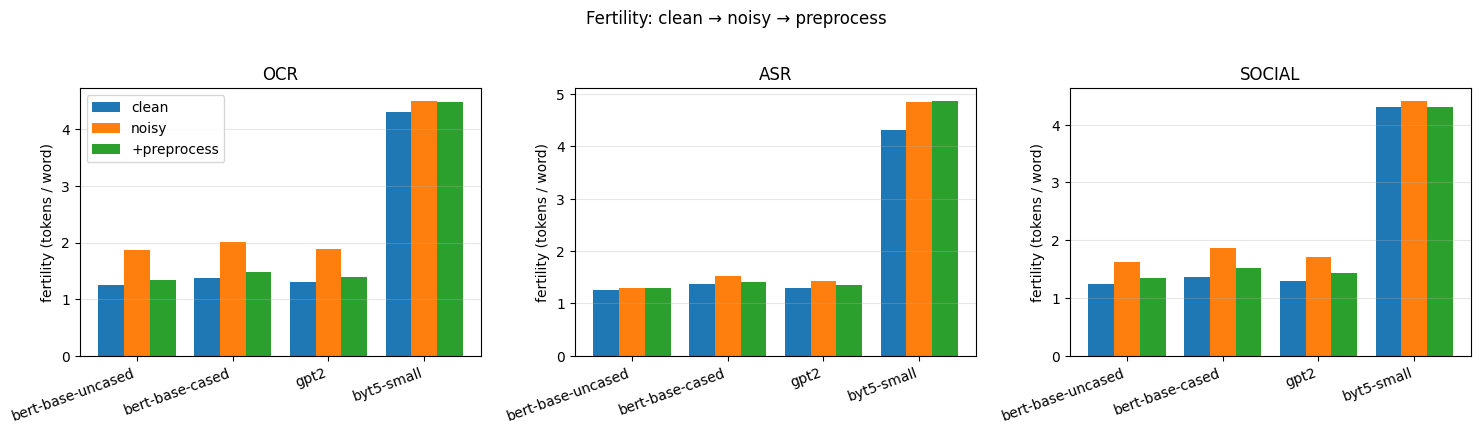

In [10]:
noises = ["ocr", "asr", "social"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
x = np.arange(len(MODEL_NAMES))
w = 0.27

for ax, noise in zip(axes, noises):
    sub = story[story["noise"] == noise].set_index("model").reindex(MODEL_NAMES)
    ax.bar(x - w, sub["fertility_clean"],      width=w, label="clean")
    ax.bar(x,     sub["fertility_noisy"],      width=w, label="noisy")
    ax.bar(x + w, sub["fertility_preprocess"], width=w, label="+preprocess")
    ax.set_title(noise.upper())
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("google/", "") for m in MODEL_NAMES], rotation=20, ha="right")
    ax.set_ylabel("fertility (tokens / word)")
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(loc="upper left")
fig.suptitle("Fertility: clean → noisy → preprocess", y=1.02)
fig.tight_layout()
plt.show()

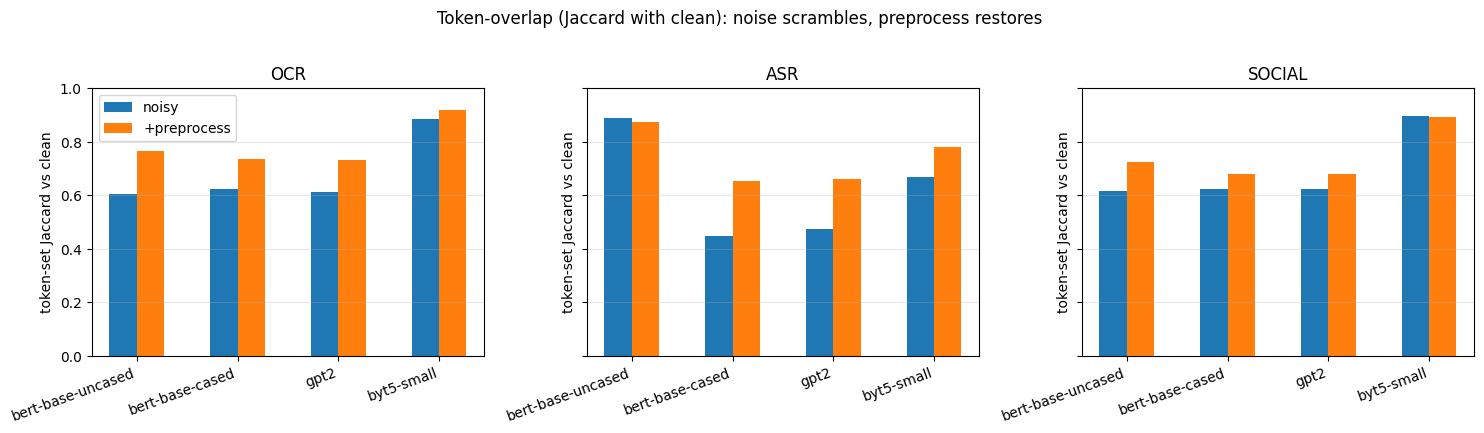

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, noise in zip(axes, noises):
    sub = story[story["noise"] == noise].set_index("model").reindex(MODEL_NAMES)
    ax.bar(x - w/2, sub["overlap_noisy"],      width=w, label="noisy")
    ax.bar(x + w/2, sub["overlap_preprocess"], width=w, label="+preprocess")
    ax.set_title(noise.upper())
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("google/", "") for m in MODEL_NAMES], rotation=20, ha="right")
    ax.set_ylabel("token-set Jaccard vs clean")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
axes[0].legend(loc="upper left")
fig.suptitle("Token-overlap (Jaccard with clean): noise scrambles, preprocess restores", y=1.02)
fig.tight_layout()
plt.show()

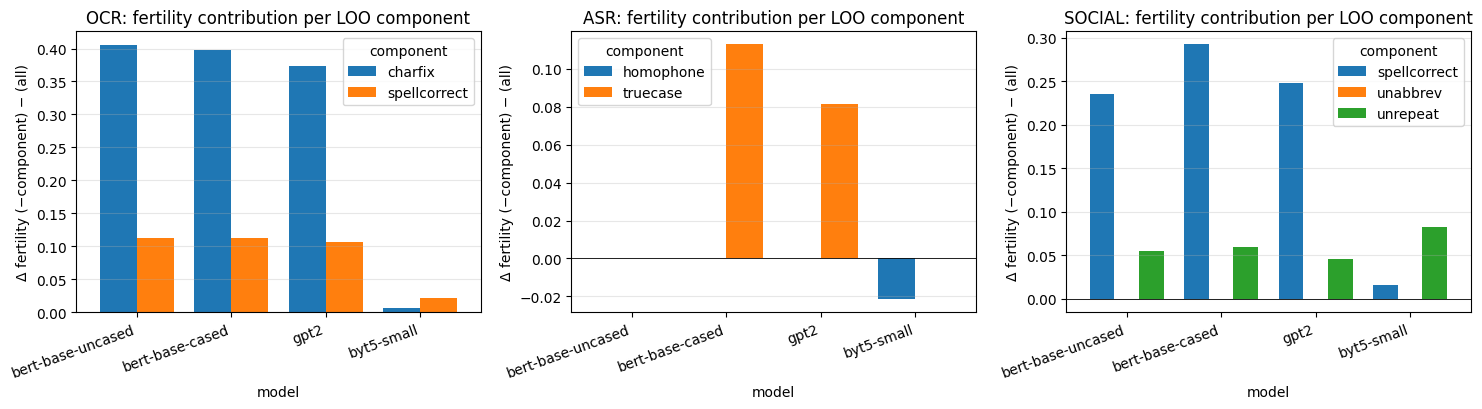

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
for ax, noise in zip(axes, noises):
    sub = contrib[contrib["noise"] == noise]
    pivot = sub.pivot(index="model", columns="component", values="fertility_contribution").reindex(MODEL_NAMES)
    pivot.plot(kind="bar", ax=ax, width=0.78)
    ax.set_title(f"{noise.upper()}: fertility contribution per LOO component")
    ax.axhline(0, color="k", linewidth=0.6)
    ax.set_ylabel("Δ fertility (−component) − (all)")
    ax.set_xticklabels([m.replace("google/", "") for m in pivot.index], rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Headline takeaways

- UNK / OOV are **0 everywhere** — modern subword + byte-level tokenizers cannot OOV by construction. "Coverage" reduces to *fertility inflation* + *token-set drift* under noise.
- Fertility under OCR jumps the most (e.g. BERT-uncased 1.27 → 1.87, +47%). ByT5 is structurally noise-robust at the tokenizer level (4.31 → ~4.5).
- Token-overlap (Jaccard vs clean) drops most under OCR; preprocess restores it materially (charfix is the main driver — see LOO contributions).
- The fertility contributions per LOO component align directionally with the F1 contributions in `preprocess_contributions.csv`: the same components that recover F1 (truecase for ASR on cased models, charfix for OCR) also bring fertility back toward the clean reference. → tokenization stability is the causal channel.

Outputs ready for the poster:
- `results/tables/tokenizer_stats_full.csv`
- `results/tables/tokenizer_contributions.csv`
- `results/tables/tokenizer_story.csv`